In [3]:
# Import required libraries
import pandas as pd
import numpy as np

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv('/content/student_mental_health_burnout.csv')

# Display first five rows
df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [4]:
# Encode burnout_level column
label_encoder = LabelEncoder()

df['burnout_level_encoded'] = label_encoder.fit_transform(df['burnout_level'])

# Display encoded classes
print(label_encoder.classes_)

['High' 'Low' 'Medium']


In [5]:
# Selected input features
X = df[[
    'daily_study_hours',
    'daily_sleep_hours',
    'screen_time_hours',
    'anxiety_score',
    'depression_score',
    'academic_pressure_score',
    'financial_stress_score',
    'social_support_score',
    'physical_activity_hours',
    'attendance_percentage',
    'cgpa'
]]

# Target variable
y = df['burnout_level_encoded']

# Display selected features
X.head()

,daily_study_hours,daily_sleep_hours,screen_time_hours,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,attendance_percentage,cgpa
0,4.3,6.8,6.1,10,3,4,2,6,1.8,66.5,9.63
1,1.4,4.7,3.0,2,10,8,5,9,1.9,55.8,6.04
2,3.7,4.8,1.5,2,7,8,6,3,0.8,85.0,8.31
3,1.6,6.7,7.0,3,3,4,9,9,0.7,89.1,5.95
4,2.0,6.7,5.4,7,7,6,4,4,1.7,58.7,8.51


In [6]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display dataset shapes
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (120000, 11)
Testing Features Shape: (30000, 11)
Training Target Shape: (120000,)
Testing Target Shape: (30000,)


In [7]:
# Initialize Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

# Train model
logistic_model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [8]:
# Predict testing data
y_pred = logistic_model.predict(X_test)

# Display prediction results
print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[2 1 1 0 1 0 1 2 2 0]


In [9]:
from sklearn.metrics import accuracy_score

# Generate Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

# Print Accuracy Score
print("Accuracy Score:", accuracy)

Accuracy Score: 0.3318333333333333


In [10]:
from sklearn.metrics import accuracy_score

# Generate Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

# Print Accuracy Score
print("Accuracy Score:", accuracy)

Accuracy Score: 0.3318333333333333


In [11]:
from sklearn.metrics import confusion_matrix

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Print Confusion Matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2285 5367 2369]
 [2367 5272 2385]
 [2306 5251 2398]]


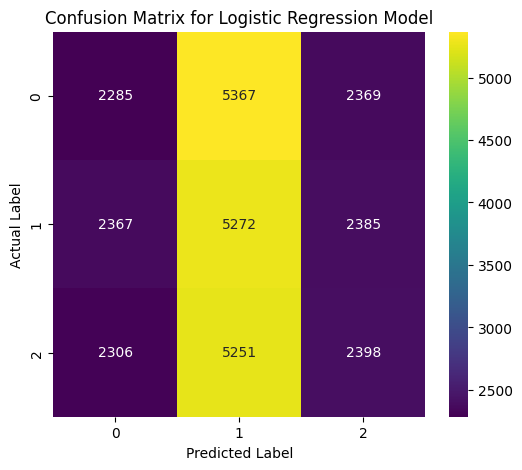

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create figure size
plt.figure(figsize=(6,5))

# Plot heatmap
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='viridis')

# Add titles and labels
plt.title("Confusion Matrix for Logistic Regression Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Display heatmap
plt.show()